# BÀI TẬP: E-COMMERCE DATA (ONLINE RETAIL)
**Nguồn:** kaggle.com/datasets/carrie1/ecommerce-data (541,909 dòng)


## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [2]:
# TODO
print("data size: ", df.shape)
print("column names: ", df.columns)
print("data types: ", df.info())

data size:  (541909, 8)
column names:  Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB
data types:  None


## A.2. Missing values & Duplicate data

In [3]:
# TODO
missing = df.isna().sum()
if missing.sum() > 0: 
    print(f"dữ liệu bị thiếu là: {missing[missing > 0]}")
else: 
    print("dữ liệu đầy đủ không bị thiếu!")

print("trùng lặp dữ liệu: ", df.duplicated().sum())

dữ liệu bị thiếu là: Description      1454
CustomerID     135080
dtype: int64
trùng lặp dữ liệu:  5268


## A.3. Invalid values

In [8]:
# TODO
print("unitPrice < 0: ", (df['UnitPrice'] < 0).sum())
print("nhận xét: ")
print("ta thấy trong unitPrice có 2 giá trị bất thường (< 0)")
print("kết luận: dữ liệu không được sạch")

unitPrice < 0:  2
nhận xét: 
ta thấy trong unitPrice có 2 giá trị bất thường (< 0)
kết luận: dữ liệu không được sạch


## A.4. Create a new column
Làm sạch dữ liệu (loại Quantity<=0, UnitPrice<=0), tạo cột `Sales` = Quantity * UnitPrice.

In [ ]:
# TODO
df_clean = df.drop(df[(df['Quantity'] <= 0) & (df['UnitPrice'] <= 0)].index)
print("dataFrame clean: ")
print(df_clean)
df_clean['Sales'] = df['Quantity'] * df['UnitPrice']
df_clean

dataFrame clean: 
       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  CustomerID        

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [ ]:
# TODO
for col in ['Quantity', 'UnitPrice']: 
    mean, median, mode = df_clean[col].mean(), df_clean[col].median(), df_clean[col].mode()[0]
    print(f"___{col}____")
    print(f"mean: {mean:.2f}, median: {median:.2f}, mode: {mode:.2f}")

___Quantity____
mean: 9.96, median: 3.00, mode: 1.00
___UnitPrice____
mean: 4.62, median: 2.08, mode: 1.25


## Group 2 — Dispersion

In [ ]:
# TODO
for col in ['Quantity', 'UnitPrice']: 
    s = df_clean[col]
    range = s.max() - s.min()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    std = s.std()
    cv = std/s.mean()
    print(f"___{col}____")
    print(f"range: {range:.2f}, std: {std:.2f}, cv: {cv:.2f}, iqr: {iqr:.2f}")

___Quantity____
range: 161990.00, std: 216.23, cv: 21.71, iqr: 9.00
___UnitPrice____
range: 50032.06, std: 96.88, cv: 20.96, iqr: 2.88


## Group 3 — Location and Shape

___Quantity____
P25: 1.0, P50: 3.0, P75: 10.0
skew: 0.30, kur: 124207.70
___UnitPrice____
P25: 1.25, P50: 2.08, P75: 4.13
skew: 186.28, kur: 58860.27


Text(0.5, 1.0, 'UnitPrice')

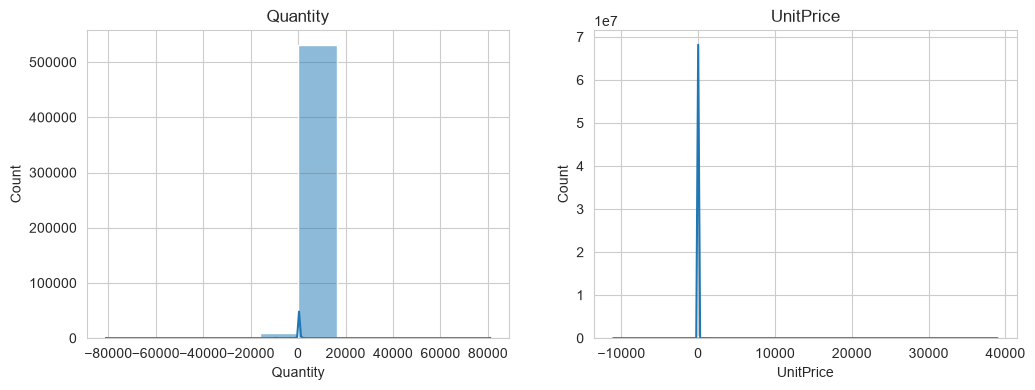

In [ ]:
# TODO
for col in ['Quantity', 'UnitPrice']: 
    s = df_clean[col]
    skew, kur = stats.skew(s), stats.kurtosis(s)
    print(f"___{col}____")
    print(f"P25: {s.quantile(0.25)}, P50: {s.quantile(0.5)}, P75: {s.quantile(0.75)}")
    print(f"skew: {skew:.2f}, kur: {kur:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_clean['Quantity'], bins=10, kde=True, ax=axes[0]);axes[0].set_title("Quantity")
sns.histplot(df_clean['UnitPrice'], bins=20, kde=True, ax=axes[1]);axes[1].set_title("UnitPrice")


---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Quốc gia nào đóng góp doanh thu cao nhất, chiếm bao nhiêu % tổng doanh thu?

In [ ]:
# TODO
group_by_countrys = df_clean.groupby('Country')['Sales'].sum().sort_values(ascending=False)
total_sales = df_clean['Sales'].sum()
percents = (group_by_countrys[group_by_countrys.index[0]] / total_sales) * 100
print(f"quốc gia {group_by_countrys.index[0]} đóng góp doanh thu cao nhất là {group_by_countrys[group_by_countrys.index[0]]}")
print(f"tỷ lệ này chiếm {percents:.2f} tổng doanh thu")

quốc gia United Kingdom đóng góp doanh thu cao nhất là 8187806.364
tỷ lệ này chiếm 84.00 tổng doanh thu


## Câu hỏi 2: Sản phẩm nào bán chạy nhất theo doanh thu?

In [ ]:
# TODO
top_product_sales = df_clean.groupby('StockCode')['Sales'].sum().sort_values(ascending=False)
print(top_product_sales)
print(f"sản phẩm bán chạy nhất là {top_product_sales.index[0]} với doanh thu là {top_product_sales.iloc[0]:.2f}")

StockCode
DOT             206245.480
22423           164762.190
47566            98302.980
85123A           97894.500
85099B           92356.030
                   ...    
BANK CHARGES     -7175.639
CRUK             -7933.430
B               -11062.060
M               -68674.190
AMAZONFEE      -221520.500
Name: Sales, Length: 3957, dtype: float64
sản phẩm bán chạy nhất là DOT với doanh thu là 206245.48


## Câu hỏi 3: Doanh số có tính mùa vụ theo tháng không?

In [ ]:
# TODO
df_clean['months'] = df_clean['InvoiceDate'].dt.month
group_by_months = df_clean.groupby('months')['Quantity'].sum().sort_values(ascending=False)
print(group_by_months)
print("doanh số tập trung cao điểm vào các tháng 10, 11, 12 => doanh số có tính theo mùa vụ rõ rệt theo tháng")


months
11    758977
10    604204
12    577745
9     567987
8     412670
7     401511
5     393557
6     386975
3     379555
1     317871
4     298531
2     283824
Name: Quantity, dtype: int64
doanh số tập trung cao điểm vào các tháng 10, 11, 12 => doanh số có tính theo mùa vụ rõ rệt theo tháng


## Câu hỏi 4: Giá trị đơn hàng trung bình (Average Order Value) khác nhau thế nào giữa các quốc gia?

In [ ]:
# TODO
total_price_of_product = df_clean.groupby(['Country', 'InvoiceNo'])['Sales'].sum().reset_index()

aov_by_country = total_price_of_product.groupby('Country')['Sales'].mean()
print(aov_by_country)
print("giá trị đơn hàng trùng bình có sự khác nhau giữa các quốc gia.")
print(f"cụ thẻ là ở quốc gia {aov_by_country.index[0]} có giá trị đơn hàng trung bình cao nhất, và thấp nhất thuộc về {aov_by_country.index[-1]}")

Country
Australia               1986.627101
Austria                  534.437895
Bahrain                  137.100000
Belgium                  343.789580
Brazil                  1143.600000
Canada                   611.063333
Channel Islands          608.675455
Cyprus                   647.314500
Czech Republic           141.544000
Denmark                  893.720952
EIRE                     731.324500
European Community       258.350000
Finland                  465.140417
France                   428.208026
Germany                  367.658723
Greece                   785.086667
Hong Kong                674.469333
Iceland                  615.714286
Israel                   878.646667
Italy                    307.100182
Japan                   1262.165000
Lebanon                 1693.880000
Lithuania                415.265000
Malta                    250.547000
Netherlands             2818.431089
Norway                   879.086500
Poland                   300.547500
Portugal            

## Câu hỏi 5: Tỷ lệ giao dịch có dấu hiệu trả hàng/hủy (Quantity âm ở dữ liệu gốc) khác nhau thế nào giữa các quốc gia?

In [ ]:
#TODO
df['cancel_order'] = df['Quantity'] < 0
cancel_rate = df.groupby('Country')['cancel_order'].mean() * 100
cancel_rate_sorted = cancel_rate.sort_values(ascending=False)
print(cancel_rate_sorted)
print("nhận xét: ")
print(f"tỷ lệ giao dịch có dấu hiệu trả hàng cao nhất thuộc về quốc gia {cancel_rate_sorted.index[0]} là {cancel_rate_sorted.iloc[0]}")

Country
USA                     38.487973
Czech Republic          16.666667
Malta                   11.811024
Japan                   10.335196
Saudi Arabia            10.000000
Australia                5.877681
Italy                    5.603985
Bahrain                  5.263158
Germany                  4.770932
EIRE                     3.684724
Poland                   3.225806
Singapore                3.056769
Sweden                   2.380952
Denmark                  2.313625
Spain                    1.894986
United Kingdom           1.855178
Belgium                  1.836636
Switzerland              1.748252
France                   1.741264
European Community       1.639344
Finland                  1.438849
Hong Kong                1.388889
Channel Islands          1.319261
Norway                   1.289134
Cyprus                   1.286174
Portugal                 1.184990
Austria                  0.748130
Greece                   0.684932
Israel                   0.673401
Nether

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

Hoạt động kinh doanh của công ty phụ thuộc lớn vào thị trường United Kingdom (chiếm 84% doanh thu) và mang tính mùa vụ rõ rệt khi doanh số bùng nổ vào các tháng cuối năm (10, 11, 12). Mặc dù UK dẫn đầu tổng doanh thu, nhưng Australia lại là thị trường chất lượng nhất về giá trị trung bình mỗi đơn hàng (AOV). Ở chiều ngược lại, công ty cần lưu ý rủi ro vận hành tại thị trường USA khi ghi nhận tỷ lệ hủy/trả hàng cao bất thường (38.5%)